# Lab 01 — The biosignal zoo & an acquisition audit

> **Type-2 lab — student version.** Fill in each `# TODO` (the answer cells raise `NotImplementedError` until you do), answer the **Checkpoint** questions, and complete the reflection cell, then re-run top to bottom. The instructor solution lives in `labs/solutions/` and is not included here.

**Covers.** Chapter 1 — §1.4 (biosignal signatures), §1.6 (the taxonomy), §1.8 (task types), §1.9 (the pipeline).

**Biomedical question.** Is this recording fit for the question I want to ask of it?
**Task type (§1.8).** Representation + Detection + Estimation (pre-analysis quality audit)
**Information that must be preserved.** the band and morphology the downstream task needs (e.g. ECG ST content to 0.05 Hz)
**Main assumptions.** channels are labelled with correct units and sampling rates
**Primary diagnostic.** an acquisition audit: rate, missingness, clipping fraction, flatline, mains estimate
**Transfer challenge.** repeat the audit on a signal type you did not design for

*Self-contained: runs fully offline in a browser on a seeded synthetic signal — no data
files, no network. `load_signal()` calls a `load_from_open_dataset()` hook you can wire to a
real recording (wfdb / MNE / PhysioNet); it is **not** wired here, so the notebook announces
the fallback and continues.*

### Companion lab · *Biomedical Signal Processing & Data Analytics* (CM2013)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/labs/lab01_biosignal_zoo_and_acquisition_audit/lab01_biosignal_zoo_and_acquisition_audit.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/lab01_biosignal_zoo_and_acquisition_audit.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=lab01_biosignal_zoo_and_acquisition_audit.ipynb)

In [5]:
# --- shared setup (reproducible; offline fallback) ---
import numpy as np, matplotlib.pyplot as plt
from scipy import signal as sig
rng = np.random.default_rng(2013)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

def load_from_open_dataset(kind, fs, secs):
    """Real-data hook — fill in for your track (wfdb / MNE / PhysioNet). Not wired by
    default, so this lab runs fully offline on synthetic data."""
    raise NotImplementedError("real-data hook not configured")

def load_signal(kind, fs, secs):
    """Return (x, fs). Try the real-data hook; else ANNOUNCE and use a synthetic stand-in."""
    try:
        return load_from_open_dataset(kind, fs, secs)
    except NotImplementedError as e:
        print(f"[load_signal] {e}; using synthetic fallback.")
        t = np.arange(int(fs*secs))/fs
        return synth(kind, t, fs), fs

def synth(kind, t, fs):
    if kind == "ecg":
        beat = lambda tc: (1.0*np.exp(-((t-tc)/0.010)**2) - 0.15*np.exp(-((t-tc+0.04)/0.02)**2)
                           + 0.25*np.exp(-((t-tc-0.22)/0.03)**2))
        x = sum(beat(tc) for tc in np.arange(0.6, t[-1], 0.85))
        x += 0.05*np.sin(2*np.pi*50*t) + 0.02*rng.standard_normal(t.size)   # mains + noise
        x += 0.1*np.sin(2*np.pi*0.3*t)                                       # baseline wander
        return x
    return np.sin(2*np.pi*10*t) + 0.2*rng.standard_normal(t.size)


## 1. See it — load and look
Load a synthetic ECG and plot 5 s. Name three features you can see.

[load_signal] real-data hook not configured; using synthetic fallback.


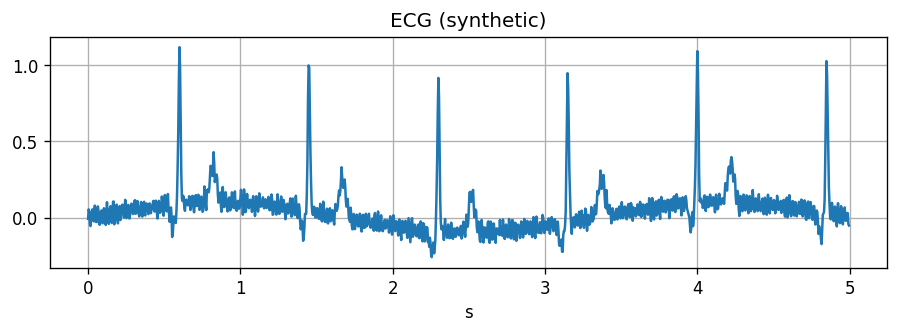

In [6]:
x, fs = load_signal("ecg", fs=250, secs=20)
t = np.arange(x.size)/fs
plt.figure(figsize=(9,2.5)); plt.plot(t[:5*fs], x[:5*fs]); plt.xlabel("s"); plt.title("ECG (synthetic)"); plt.show()
# Checkpoint: which artifacts are visible? (baseline wander? mains? noise?)
# I see baseline wander (PT waveforms aren't relatively flat, rather the mean varies), and mains artifcat, where the baseline appears to be
# at a higher frequency, creating a blurry line.

## 2. Build the acquisition audit
`# TODO` complete each metric. This one-page audit is the first thing you run on ANY new recording.

In [7]:
def acquisition_audit(x, fs):
    audit = {}
    audit["duration_s"] = x.size / fs
    audit["fs"] = fs
    # missingness: fraction of NaN samples  (worked for you — the pattern for the rest)
    audit["missing_frac"] = float(np.mean(np.isnan(x)))

    # TODO clipping: a saturated ADC RAILS -- it pins the SAME extreme code for a run of
    #   samples (a flat plateau at min or max). Flag a sample only if it sits AT a rail AND
    #   repeats its neighbour, so a lone R-peak does not count. Set audit["clip_frac"].
    # raise NotImplementedError("TODO: implement this — see the comment above")
    min_val = np.min(x)
    max_val = np.max(x)
    num_clipped = 0
    for i in range(x.size):
      if x[i] == min_val:
        if (i != (x.size - 1)) and (i != 0): # makes sure that this isnt the first or last element
          if (x[i + 1]) == min_val or (x[i - 1]) == min_val:
            num_clipped += 1
        if (i == 0): # first element
          if (x[i + 1]) == min_val:
            num_clipped += 1
        if (i == (x.size - 1)):
          if (x[i - 1]) == min_val:
            num_clipped += 1
      if x[i] == max_val:
        if (i != (x.size - 1)) and (i != 0): # makes sure that this isnt the first or last element
          if (x[i + 1]) == max_val or (x[i -1]) == max_val:
            num_clipped += 1
        if (i == 0): # first element
          if (x[i + 1]) == max_val:
            num_clipped += 1
        if (i == (x.size - 1)):
          if (x[i - 1]) == max_val:
            num_clipped += 1
    audit["clip_frac"] = num_clipped / x.size

    # TODO flatline: fraction of samples inside 1-SECOND windows whose peak-to-peak spread is a
    #   tiny fraction of the signal's scale (a dead / disconnected lead). Set audit["flat_frac"].
    # raise NotImplementedError("TODO: implement this — see the comment above")
    num_flat = 0;
    for i in range(x.size // fs):
      x_new = x[i * fs:(i + 1) * fs]
      spread = np.max(x_new) - np.min(x_new) # peak-to-peak spread
      if spread / (max_val - min_val) <= 0.01:
        num_flat += 1
    audit["flat_frac"] = num_flat / (x.size // fs)

    # TODO mains: power in a narrow 50 Hz band vs total (use sig.welch). Set audit["mains50_frac"].
    # raise NotImplementedError("TODO: implement this — see the comment above")
    freq, pwr = sig.welch(x, fs)
    band_low = 49 # narrow band
    band_high = 51 # narrow band
    band = (freq >= band_low) & (freq <= band_high)
    narrow_pwr = np.sum(pwr[band])
    tot_pwr = np.sum(pwr)
    audit["mains50_frac"] = narrow_pwr / tot_pwr
    return audit

acquisition_audit(x, fs)  # Checkpoint: is the mains fraction high enough to worry about?
# the mains fraction is equal to approximately 6% which is significantly high enough to be wary about how there may be electrical interference
# with the ECG. Whether or not I would be worried about it would depend on the context of the situation / reading.

{'duration_s': 20.0,
 'fs': 250,
 'missing_frac': 0.0,
 'clip_frac': 0.0,
 'flat_frac': 0.0,
 'mains50_frac': np.float64(0.05948570639312266)}

### Do the clipping/flatline detectors actually react to defects?
A metric you never see fire is untrustworthy. The clean ECG has neither defect, so both must read ~0; a hard-limited copy must trip `clip_frac`, and a spliced dead-lead segment must trip `flat_frac`.

In [8]:
# --- sanity check: react to REAL defects, not to healthy peaks (numbers are computed live) ---
x_clipped = np.clip(x, -0.55, 0.55)                 # hard-limit -> the ADC 'rails'
x_dead = x.copy(); x_dead[3*fs:5*fs] = x_dead[3*fs]  # splice a 2 s disconnected-lead flatline
a0 = acquisition_audit(x, fs)
print(f"clean     : clip_frac={a0['clip_frac']:.4f}   flat_frac={a0['flat_frac']:.4f}")
print(f"clipped   : clip_frac={acquisition_audit(x_clipped, fs)['clip_frac']:.4f}   (was ~0 on clean)")
print(f"dead-lead : flat_frac={acquisition_audit(x_dead, fs)['flat_frac']:.4f}   (2 s of 20 s ~ 0.10)")

clean     : clip_frac=0.0000   flat_frac=0.0000
clipped   : clip_frac=0.0184   (was ~0 on clean)
dead-lead : flat_frac=0.1000   (2 s of 20 s ~ 0.10)


## 3. Make it fail — the wrong bandwidth
High-pass the ECG as if for *rhythm monitoring*, then ask whether it still supports *ST analysis*.

Before:  0.00023045706583943475
After:  0.00019564961764328506


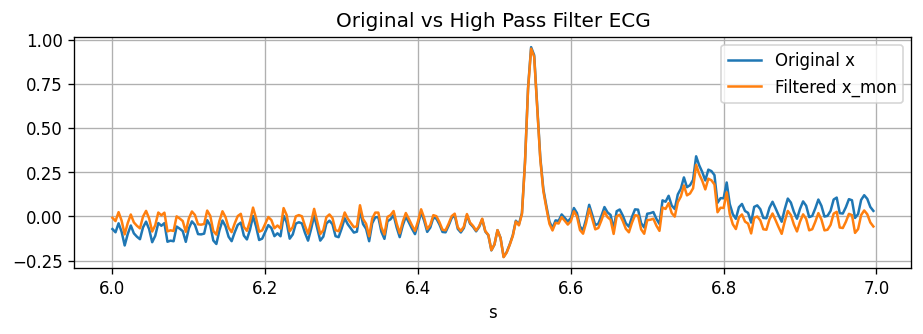

In [16]:
# TODO apply a 0.5 Hz high-pass (monitoring-style) and compare the low-frequency content.
# raise NotImplementedError("TODO: implement this — see the comment above")
freq, pwr = sig.welch(x, fs)
low_band = (freq < 0.5)
low_before = np.sum(pwr[low_band])
b, a = sig.butter(5, 0.5, btype="highpass", fs=fs) # high pass filter, 5th order
x_mon = sig.filtfilt(b, a, x) # forward/back lin filter
freq_after, pwr_after = sig.welch(x_mon, fs)
low_band_after = (freq_after < 0.5)
low_after = np.sum(pwr_after[low_band_after])
print("Before: ", low_before)
print("After: ", low_after)

# Checkpoint: plot x vs x_mon around a beat. What happened to the slow ST/T region?
# raise NotImplementedError("TODO: implement this — see the comment above")
start = 6 * fs
end = 7 * fs
t = np.arange(start, end) / fs
plt.figure(figsize=(9,2.5))
plt.plot(t, x[start:end], label = "Original x")
plt.plot(t, x_mon[start:end], label = "Filtered x_mon")
plt.xlabel("s")
plt.title("Original vs High Pass Filter ECG")
plt.legend()
plt.show()
# Applying a 0.5Hz high pass filter was able to reduce some nosie and fluctuation
# that occurs after the QRS wave, allowing the filtered signal to remain stable.
# Important to note that even with the filter, the two lines are practically the
# the same wave during the QRS wave.


## Reflection
1. Which conclusion about signal quality stayed stable across reasonable audit thresholds?
2. Which changed?
3. What evidence would you need before using this recording on a new population or device?
4. Which method would you investigate next, and why?

1a. Displayed that the original recording can be trusted when sent through the auditing coding lines that can positively dispaly any railing / plateauing the monitor may reach.
2a. Changes to the waveform occured when applying a highpass filter revealing the importance that preprocessing has to clean up a signal.
3a. I would feel more comfortable using it on new populations / devices once it has undergone further vaidity testing on known data sources.
4a. I would explore the different cut-off frequency values for the high-pass filters. With the current high-pass filters, the signal after the QRS wave appeared to experience some baseline drift. Try to find the lowest cut-off frequency that keeps the desired signals intact while simultaneously filtering out external signals that cause noise on the monitor.